In [1]:
from loadPressureData import loadPressureData, matlab_datenum_to_datetime64
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from BulkWaveStats import detide, Spp_to_Seta, sig_wave_height
from scipy.signal import spectrogram
from eta_f import compute_eta_f
import pandas as pd



This notebook follows the computations performed on Becker(2014) *Water Level Effects on breaking wave setup for Pacific Island fringing reefs*

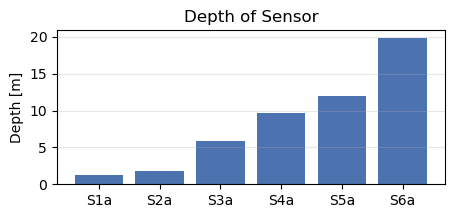

In [2]:
# need to decide where the reef flat/reef face is 
labels = ['S1a', 'S2a', 'S3a', 'S4a', 'S5a', 'S6a']
depths = [1.3, 1.74, 5.90, 9.64, 11.95, 19.9]

fig, ax = plt.subplots(figsize=(5, 2))
ax.bar(labels, depths, color="#4C72B0")
ax.set_ylabel("Depth [m]")
ax.set_title("Depth of Sensor")
ax.grid(axis="y", alpha=0.3)
plt.show()

since sensor 1 and 2 are ~same depth, i'm going to assumer that sensor 3 is the end of the reef face and sensor 6 is the "offshore" sensor but will talk to mark about that. 

In [ ]:
### ------------------ LOAD AND DETIDE DATA -------------------- ###

# INPUT VALUES
fs = 1
nperseg = 131072 # 2 hr windows
noverlap = nperseg * 0.75 # 75% overlap
LAT = 21.58055556

## ----- Sensor 1 (NEARSHORE)----- ##
bursts1 = loadPressureData(Path("data/MoA18411.mat"))
t1, h1, p1 = bursts1.time, bursts1.depth_m, bursts1.pressure_pa
# detide
tide1, p1_detide, p1_raw = detide(p1, t1, LAT = LAT)
# PSD of eta
freqs1, t1_spec, Spp1 = spectrogram(p1_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta1, t_eta1, h_eta1 = Spp_to_Seta(Spp1, freqs1, t1_spec, t1, h1)


## ----- Sensor 4/5 (REEF FACE)----- ##
bursts4 = loadPressureData(Path("data/MoA48411.mat"))
t4, h4, p4 = bursts4.time, bursts4.depth_m, bursts4.pressure_pa
# detide
tide4, p4_detide, p4_raw = detide(p4, t4, LAT = LAT)
# PSD of eta
freqs4, t4_spec, Spp4 = spectrogram(p4_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta4, t_eta4, h_eta4 = Spp_to_Seta(Spp4, freqs4, t4_spec, t4, h4)

bursts4b = loadPressureData(Path("data/MoA48411.mat"))
t4b, h4b, p4b = bursts4.time, bursts4.depth_m, bursts4.pressure_pa
# detide
tide4b, p4b_detide, p4b_raw = detide(p4b, t4b, LAT = LAT)
# PSD of eta
freqs4b, t4b_spec, Spp4b = spectrogram(p4b_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta4b, t_eta4b, h_eta4b = Spp_to_Seta(Spp4b, freqs4b, t4b_spec, t4b, h4b)

bursts5 = loadPressureData(Path("data/MoA58411.mat"))
t5, h5, p5 = bursts5.time, bursts5.depth_m, bursts5.pressure_pa
# detide
tide5, p5_detide, p5_raw = detide(p5, t5,  LAT = LAT)
freqs5, t5_spec, Spp5 = spectrogram(p5_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta5, t_eta5, h_eta5 = Spp_to_Seta(Spp5, freqs5, t5_spec, t5, h5)

## ----- Sensor 6 (OFFSHORE)----- ##
bursts6 = loadPressureData(Path("data/MoA68411.mat"))
t6, h6, p6 = bursts6.time, bursts6.depth_m, bursts6.pressure_pa
# detide
tide6, p6_detide, p6_raw = detide(p6, t6, LAT = LAT)
# PSD of eta
freqs6, t6_spec, Spp6 = spectrogram(p6_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta6, t_eta6, h_eta6 = Spp_to_Seta(Spp6, freqs6, t6_spec, t6, h6)

NameError: name 'LAT' is not defined

Text(0.5, 1.0, 'detided elevation autspectra with nperseg=131072')

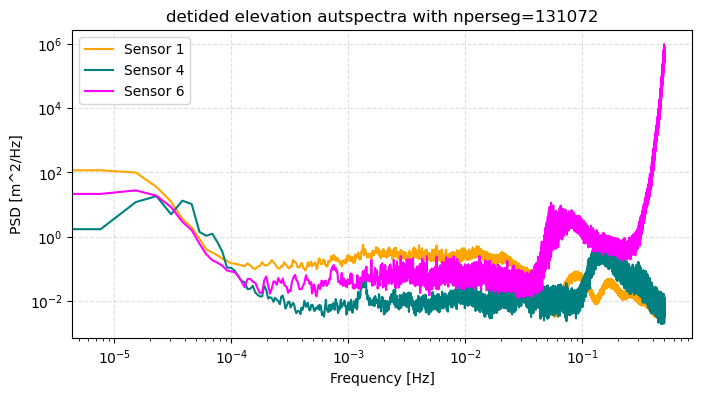

In [4]:
# INPUT VALUES
fs = 1
nperseg = 131072 # 2 hr windows
noverlap = nperseg * 0.75 # 75% overlap

# compute pressure spectra ---> convert to sfc elevation spectra
freqs1, t1_spec, Spp1 = spectrogram(p1_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta1, t_eta1, h_eta1 = Spp_to_Seta(Spp1, freqs1, t1_spec, t1, h1)

freqs4, t4_spec, Spp4 = spectrogram(p4_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta4, t_eta4, h_eta4 = Spp_to_Seta(Spp4, freqs4, t4_spec, t4, h4)

freqs6, t6_spec, Spp6 = spectrogram(p6_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta6, t_eta6, h_eta6 = Spp_to_Seta(Spp6, freqs6, t6_spec, t6, h6)

## ------- Autospectra plot ------ ##

autospec1 = np.nanmean(Seta1, axis=1)  
autospec4 = np.nanmean(Seta4, axis=1)  
autospec6 = np.nanmean(Seta6, axis=1)  

fig, ax = plt.subplots(figsize=(8,4))

ax.loglog(freqs1, autospec1, color='orange', label = 'Sensor 1')
ax.loglog(freqs4, autospec4, color='teal', label = 'Sensor 4')
ax.loglog(freqs6, autospec6, color='magenta', label = 'Sensor 6')
#ax.set_xlim(None,0.08)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('PSD [m^2/Hz]')
ax.legend()
ax.set_title('detided elevation autspectra with nperseg={}'.format(nperseg))


In [5]:
# INPUT VALUES
fs = 1
nperseg = 7200 # 2 hr windows
noverlap = nperseg * 0.75 # 75% overlap

# compute pressure spectra ---> convert to sfc elevation spectra
freqs1, t1_spec, Spp1 = spectrogram(p1_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta1, t_eta1, h_eta1 = Spp_to_Seta(Spp1, freqs1, t1_spec, t1, h1)

freqs4, t4_spec, Spp4 = spectrogram(p4_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta4, t_eta4, h_eta4 = Spp_to_Seta(Spp4, freqs4, t4_spec, t4, h4)

freqs6, t6_spec, Spp6 = spectrogram(p6_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta6, t_eta6, h_eta6 = Spp_to_Seta(Spp6, freqs6, t6_spec, t6, h6)

In [43]:
ds_etaf

<xarray.Dataset> Size: 16kB
Dimensions:  (time: 336)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2007-12-14T01:00:00 ... 2007-12-28
Data variables:
    eta_f    (time) float64 3kB -0.001585 -0.001578 ... -0.0007936 -0.001034
    H_rms    (time) float64 3kB 0.5037 0.5078 0.5298 ... 0.299 0.3413 0.3853
    k_f      (time) float64 3kB 0.1403 0.1417 0.1429 ... 0.1317 0.1257 0.1276
    h_f      (time) float64 3kB 6.258 6.297 6.028 5.922 ... 6.179 6.256 6.135
    f_rep    (time) float64 3kB 0.1568 0.1584 0.1574 ... 0.1483 0.1432 0.1441
Attributes:
    equation:  eta_f = -(H_f^2 k_f) / (8 sinh(2 k_f h_f))
    band:      (0.05, 0.33)

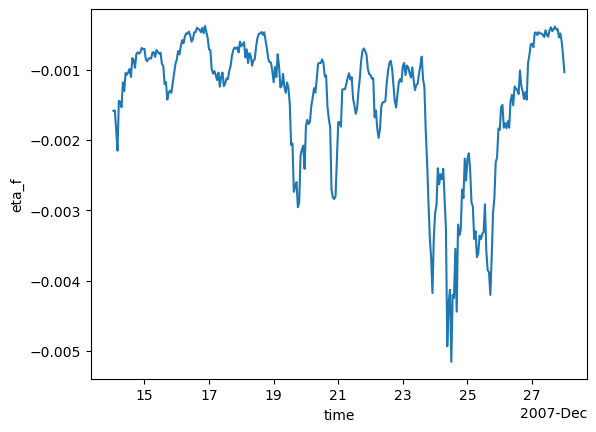

In [46]:
ds_etaf = compute_eta_f(Seta4,freqs4,t4_spec,t4,-h4,)
ds_etaf.eta_f.plot()
eta_f = ds_etaf.eta_f.values



In [38]:
ds_etaf

<xarray.Dataset> Size: 16kB
Dimensions:  (time: 336)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2007-12-14T01:00:00 ... 2007-12-28
Data variables:
    eta_f    (time) float64 3kB -0.001585 -0.001578 ... -0.0007936 -0.001034
    H_rms    (time) float64 3kB 0.5037 0.5078 0.5298 ... 0.299 0.3413 0.3853
    k_f      (time) float64 3kB 0.1403 0.1417 0.1429 ... 0.1317 0.1257 0.1276
    h_f      (time) float64 3kB 6.258 6.297 6.028 5.922 ... 6.179 6.256 6.135
    f_rep    (time) float64 3kB 0.1568 0.1584 0.1574 ... 0.1483 0.1432 0.1441
Attributes:
    equation:  eta_f = -(H_f^2 k_f) / (8 sinh(2 k_f h_f))
    band:      (0.05, 0.33)

#### debugging eta_f

In [ ]:
import math

In [ ]:
# INPUT
BAND = (0.04,0.4)

h4_spec, times4 = _depth_at_centers(t4_spec, t4, h4)
freq4_rep = _representative_frequency(Seta4, freqs4, BAND)
Hrms, t4_Hrms = compute_hrms(Seta4, freqs4, t4_spec, t4, h4, BAND)
kf = compute_kf(freq4_rep, -h4_spec)


In [ ]:
kf.shape, freq4_rep.shape, times4.shape, Seta4.shape

((336,), (336,), (336,), (3601, 336))

In [ ]:
# 0 nans in h4_spec from _depth_at_centers
# t4_Hrms and times 4 are the same so far
def compute_eta_f(
    Seta: np.ndarray,
    freqs: np.ndarray,
    t_spec: np.ndarray,
    t1: np.ndarray,
    h1: np.ndarray,
    *,
    band: Tuple[float, float] = (0.05, 0.33),
    depth_interp: np.ndarray | None = None,
    output: str = "xarray",
):
    """
    Evaluate equation (4) from Becker (2014) for a given spectrogram.

    Parameters
    ----------
    Seta, freqs, t_spec, t1, h1
        Surface elevation spectra and metadata produced by `Spp_to_Seta`.
    band
        Frequency interval [Hz] used to compute Hrms and representative
        frequency. Defaults to the sea/swell band.
    depth_interp
        Optionally supply a pre-interpolated depth series to avoid repeating
        the interpolation performed in other routines.
    output
        ``"xarray"`` (default) returns an ``xr.Dataset`` when xarray is
        available. Set to ``"dataframe"`` to always receive a
        ``pandas.DataFrame``.
    """
    hrms, time_centers = compute_hrms(
        Seta,
        freqs,
        t_spec,
        t1,
        h1,
        band,
        depth_interp=depth_interp,
    )
    depth_at_centers, time_centers_check = _depth_at_centers(
        t_spec,
        t1,
        h1,
        depth_interp=depth_interp,
    )
    if not np.all(time_centers == time_centers_check):
        # Align arrays if sig_wave_height and our interpolation applied
        # slightly different rounding.
        time_centers = time_centers_check

    freq_rep = _representative_frequency(Seta, freqs, band)
    k_vals = compute_kf(freq_rep, depth_at_centers)

    denominator = 8.0 * np.sinh(2.0 * k_vals * depth_at_centers)
    eta_vals = np.full_like(hrms, np.nan, dtype=float)
    mask = (denominator != 0.0) & np.isfinite(k_vals) & np.isfinite(hrms)
    eta_vals[mask] = -((hrms[mask] ** 2) * k_vals[mask]) / denominator[mask]

    if output.lower() == "dataframe" or xr is None:
        df = pd.DataFrame(
            {
                "eta_f": eta_vals,
                "H_rms": hrms,
                "k_f": k_vals,
                "h_f": depth_at_centers,
                "f_rep": freq_rep,
            },
            index=pd.to_datetime(time_centers),
        )
        df.index.name = "time"
        df.attrs = {
            "equation": "eta_f = -(H_f^2 k_f) / (8 sinh(2 k_f h_f))",
            "band": band,
        }
        return df

    dataset = xr.Dataset(
        data_vars={
            "eta_f": ("time", eta_vals),
            "H_rms": ("time", hrms),
            "k_f": ("time", k_vals),
            "h_f": ("time", depth_at_centers),
            "f_rep": ("time", freq_rep),
        },
        coords={"time": pd.to_datetime(time_centers)},
        attrs={
            "equation": "eta_f = -(H_f^2 k_f) / (8 sinh(2 k_f h_f))",
            "band": band,
        },
    )
    return dataset





In [ ]:
times4


array(['2007-12-14T01:00:00.000000000', '2007-12-14T02:00:00.000000000',
       '2007-12-14T03:00:00.000000000', '2007-12-14T04:00:00.000000000',
       '2007-12-14T05:00:00.000000000', '2007-12-14T06:00:00.000000000',
       '2007-12-14T07:00:00.000000000', '2007-12-14T08:00:00.000000000',
       '2007-12-14T09:00:00.000000000', '2007-12-14T10:00:00.000000000',
       '2007-12-14T11:00:00.000000000', '2007-12-14T12:00:00.000000000',
       '2007-12-14T13:00:00.000000000', '2007-12-14T14:00:00.000000000',
       '2007-12-14T15:00:00.000000000', '2007-12-14T16:00:00.000000000',
       '2007-12-14T17:00:00.000000000', '2007-12-14T18:00:00.000000000',
       '2007-12-14T19:00:00.000000000', '2007-12-14T20:00:00.000000000',
       '2007-12-14T21:00:00.000000000', '2007-12-14T22:00:00.000000000',
       '2007-12-14T23:00:00.000000000', '2007-12-15T00:00:00.000000000',
       '2007-12-15T01:00:00.000000000', '2007-12-15T02:00:00.000000000',
       '2007-12-15T03:00:00.000000000', '2007-12-15